# 4. 신경망(Neural Network)과 MLP — 실습 노트북

---

---
## 0. 환경 설정

In [1]:
%pip install torch
%pip install numpy
%pip install matplotlib
%pip install seaborn

   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.4/113.7 MB 12.2 MB/s eta 0:00:10
    --------------------------------------- 2.1/113.7 MB 33.0 MB/s eta 0:00:04
    --------------------------------------- 2.1/113.7 MB 33.0 MB/s eta 0:00:04
    --------------------------------------- 2.1/113.7 MB 33.0 MB/s eta 0:00:04
    --------------------------------------- 2.7/113.7 MB 12.3 MB/s eta 0:00:10
   -- ------------------------------------- 6.1/113.7 MB 22.9 MB/s eta 0:00:05
   --- ------------------------------------ 9.2/113.7 MB 29.4 MB/s eta 0:00:04
   ---- ----------------------------------- 12.4/113.7 MB 72.6 MB/s eta 0:00:02
   ----- ---------------------------------- 15.6/113.7 MB 65.6 MB/s eta 0:00:02
   ------ --------------------------------- 18.5/113.7 MB 65.6 MB/s eta 0:00:02
   ------- -------------------------------- 21.4/113.7 MB 65.6 MB/s eta 0:00:02
   -------- ------------------------------- 24.4/113.7 M


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 딥러닝 라이브러리
import torch              # PyTorch 기본 라이브러리
import torch.nn as nn     # 신경망 구성 요소 (레이어, 활성화 함수 등)
import torch.optim as optim  # 최적화 알고리즘 (SGD, Adam 등)

# 데이터 처리 및 시각화
import numpy as np        # 수치 계산 라이브러리
import matplotlib.pyplot as plt  # 그래프 시각화

# 설치된 PyTorch 버전 확인
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
CUDA available: False


---
# 실습 1: PyTorch (교안 슬라이드 6)

> **교안 연결**: 딥러닝은 인공신경망을 사용합니다. 이 인공신경망을 코드로 구현하는 도구가 **PyTorch**입니다.  
> PyTorch의 기본 자료구조인 **텐서(Tensor)**부터 익혀봅시다.

### 텐서란?
- NumPy의 배열(array)과 거의 동일하지만, **GPU 연산**과 **자동 미분**을 지원합니다.
- PyTorch에서 모든 데이터는 텐서로 표현됩니다.

In [3]:
# 텐서 생성하기
a = torch.tensor([1, 2, 3])               # 1차원 텐서 (벡터)
b = torch.tensor([[1, 2, 3], [4, 5, 6]])   # 2차원 텐서 (행렬)

print("1차원 텐서:", a)
print("1차원 텐서 shape:", a.shape)
print()
print("2차원 텐서:")
print(b)
print("2차원 텐서 shape:", b.shape)

1차원 텐서: tensor([1, 2, 3])
1차원 텐서 shape: torch.Size([3])

2차원 텐서:
tensor([[1, 2, 3],
        [4, 5, 6]])
2차원 텐서 shape: torch.Size([2, 3])


### NumPy vs PyTorch — 문법이 거의 동일합니다

In [4]:
# NumPy
a_np = np.array([[1, 2], [3, 4]])
b_np = np.array([[5, 6], [7, 8]])
print("NumPy 행렬곱:", (a_np + b_np) @ b_np)
print()

# PyTorch — 문법이 동일!
a_pt = torch.tensor([[1, 2], [3, 4]])
b_pt = torch.tensor([[5, 6], [7, 8]])
print("PyTorch 행렬곱:", (a_pt + b_pt) @ b_pt)

NumPy 행렬곱: [[ 86 100]
 [134 156]]

PyTorch 행렬곱: tensor([[ 86, 100],
        [134, 156]])


### Tensor로 MSE 직접 계산해보기
- 손실 함수(Loss Function)는 "예측값과 정답의 차이"를 숫자로 나타낸 것입니다.

In [5]:
# Tensor로 MSE(평균 제곱 오차) 직접 계산해보기
# MSE는 "예측값과 정답의 차이"를 숫자로 나타낸 손실 함수입니다
# from sklearn.metrics import mean_squared_error 를 구현한 것과 같음, 실제론 이걸 쓰겠지만.

def mse_loss(y_hat, y):
    """평균 제곱 오차 계산"""
    return torch.mean((y_hat - y) ** 2)

y_hat = torch.tensor([2.5, 0.0, 2.1, 7.8])  # 모델 예측값
y     = torch.tensor([3.0, -0.5, 2.0, 7.0])  # 실제 정답

print(f"MSE = {mse_loss(y_hat, y).item():.4f}")
print("→ 예측값과 정답의 차이를 제곱해서 평균 낸 값입니다.")

MSE = 0.2875
→ 예측값과 정답의 차이를 제곱해서 평균 낸 값입니다.


---
# 실습 2: nn.Linear로 퍼셉트론 체험 (교안 슬라이드 10)

> **교안 연결**: 퍼셉트론은 y = wx + b, 즉 직선 하나를 긋는 것과 같습니다.  
> PyTorch에서 이것은 **nn.Linear**로 표현됩니다.

### tips 데이터셋으로 선형회귀
- 입력: 식사 금액(total_bill)
- 출력: 팁 금액(tip)
- nn.Linear(1, 1) = 입력 1개, 출력 1개인 퍼셉트론

In [6]:
import seaborn as sns

# 데이터 준비
tips = sns.load_dataset("tips")
X = torch.tensor(tips["total_bill"].values, dtype=torch.float32).reshape(-1, 1)
y = torch.tensor(tips["tip"].values, dtype=torch.float32).reshape(-1, 1)

# 모델 정의 — 퍼셉트론 1개 = nn.Linear(1, 1)
model = nn.Linear(1, 1)

# 학습 전 가중치 확인
print(f"초기 weight: {model.weight.item():.4f}")
print(f"초기 bias:   {model.bias.item():.4f}")
print("→ 아직 학습 전이라 랜덤 값입니다.")

초기 weight: -0.9819
초기 bias:   -0.2492
→ 아직 학습 전이라 랜덤 값입니다.


In [7]:
# 학습 실행
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

for epoch in range(2000):
    y_hat = model(X)                 # 순전파: 예측
    loss = criterion(y_hat, y)       # 손실 계산
    optimizer.zero_grad()            # 기울기 초기화
    loss.backward()                  # 역전파
    optimizer.step()                 # 가중치 업데이트
    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

print(f"\n학습된 weight: {model.weight.item():.4f}")
print(f"학습된 bias:   {model.bias.item():.4f}")
print("→ tip ≈ 0.105 × total_bill + 0.92 라는 규칙을 스스로 찾았습니다!")

Epoch    0 | Loss: 608.4250
Epoch  400 | Loss: 1.1975
Epoch  800 | Loss: 1.1595
Epoch 1200 | Loss: 1.1305
Epoch 1600 | Loss: 1.1083

학습된 weight: 0.1292
학습된 bias:   0.3463
→ tip ≈ 0.105 × total_bill + 0.92 라는 규칙을 스스로 찾았습니다!


C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 494

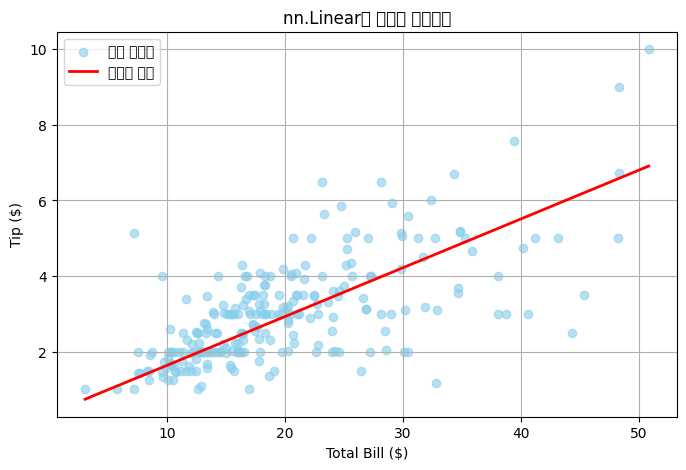

In [8]:
# 결과 시각화
with torch.no_grad():
    x_line = torch.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), color='skyblue', alpha=0.6, label='실제 데이터')
plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2, label='학습된 직선')
plt.title("nn.Linear로 학습한 선형회귀")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend()
plt.grid(True)
plt.show()

---
# 실습 3: nn.Sequential로 층 쌓기 (교안 슬라이드 15)

> **교안 연결**: 직선 하나(퍼셉트론)로는 XOR 같은 문제를 풀 수 없습니다.  
> 여러 층을 **쌓으면** 더 복잡한 문제를 풀 수 있습니다.  
> PyTorch에서 층을 쌓는 방법이 **nn.Sequential**입니다.

### 공부시간 → 합격확률 (로지스틱 회귀)

Epoch   0 | Loss: 3.4129
Epoch 100 | Loss: 0.3242
Epoch 200 | Loss: 0.2677
Epoch 300 | Loss: 0.2316
Epoch 400 | Loss: 0.2064
학습 완료!


C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

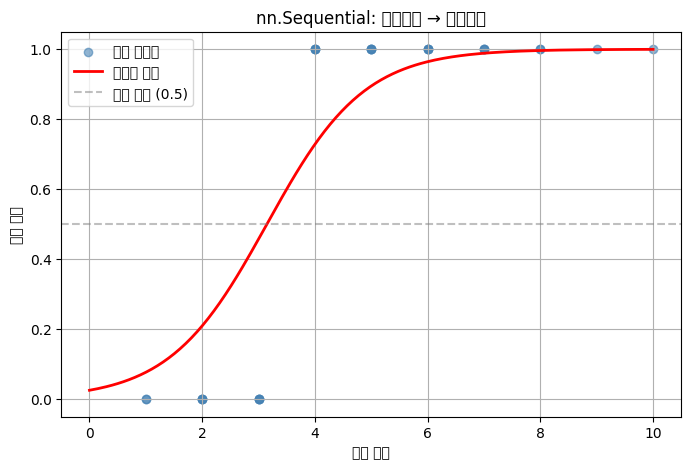

In [9]:
# 데이터: 공부시간 → 합격 여부
X = torch.tensor([
    [1.0],[2.0],[3.0],[4.0],[5.0],[6.0],
    [2.0],[3.0],[4.0],[5.0],[6.0],[7.0],
    [1.0],[2.0],[3.0],[4.0],[5.0],[6.0],
    [7.0],[8.0],[2.0],[3.0],[4.0],[5.0],
    [6.0],[7.0],[8.0],[9.0],[10.0]
])
y = torch.tensor([
    [0.0],[0.0],[0.0],[1.0],[1.0],[1.0],
    [0.0],[0.0],[1.0],[1.0],[1.0],[1.0],
    [0.0],[0.0],[0.0],[1.0],[1.0],[1.0],
    [1.0],[1.0],[0.0],[0.0],[1.0],[1.0],
    [1.0],[1.0],[1.0],[1.0],[1.0]
])

# nn.Sequential로 층 쌓기: Linear → Sigmoid
model = nn.Sequential(
    nn.Linear(1, 1),   # y = wx + b
    nn.Sigmoid()       # 0~1 사이로 변환 (확률)
)

criterion = nn.BCELoss()  # 이진 분류 손실함수
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(500):
    y_hat = model(X)
    loss = criterion(y_hat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print("학습 완료!")

# 시각화
with torch.no_grad():
    x_line = torch.linspace(0, 10, 200).reshape(-1, 1)
    y_line = model(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), color='steelblue', alpha=0.6, label='실제 데이터')
plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2, label='학습된 곡선')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='판정 기준 (0.5)')
plt.title("nn.Sequential: 공부시간 → 합격확률")
plt.xlabel("공부 시간")
plt.ylabel("합격 확률")
plt.legend()
plt.grid(True)
plt.show()

---
# 실습 4: XOR 문제를 MLP로 풀기 (교안 슬라이드 20)

> **교안 연결**: 슬라이드 11에서 퍼셉트론(직선 하나)으로는 XOR을 풀 수 없다고 배웠습니다.  
> 이제 **ReLU + 여러 층**을 사용하면 XOR이 풀리는지 직접 확인합니다.

### XOR 복습
| 입력1 | 입력2 | 정답 |
|-------|-------|------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

두 입력이 **서로 다를 때만** 1. 직선 하나로는 절대 나눌 수 없는 문제였습니다.

In [10]:
# ============================================
# 먼저: 퍼셉트론(Linear 1개)으로 XOR을 시도
# ============================================
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# 퍼셉트론 = Linear 1개 + Sigmoid
model_single = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.SGD(model_single.parameters(), lr=1.0)

# 학습
for epoch in range(1000):
    y_hat = model_single(X)
    loss = criterion(y_hat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 결과 확인
with torch.no_grad():
    preds = model_single(X)
    print("=== 퍼셉트론(Linear 1개)으로 XOR ===")
    print(f"[0,0] → {preds[0].item():.4f}  (정답: 0)")
    print(f"[0,1] → {preds[1].item():.4f}  (정답: 1)")
    print(f"[1,0] → {preds[2].item():.4f}  (정답: 1)")
    print(f"[1,1] → {preds[3].item():.4f}  (정답: 0)")
    print()
    print("→ 전부 0.5 근처! 직선 하나로는 XOR을 분류할 수 없습니다.")

=== 퍼셉트론(Linear 1개)으로 XOR ===
[0,0] → 0.5000  (정답: 0)
[0,1] → 0.5000  (정답: 1)
[1,0] → 0.5000  (정답: 1)
[1,1] → 0.5000  (정답: 0)

→ 전부 0.5 근처! 직선 하나로는 XOR을 분류할 수 없습니다.


In [11]:
# ============================================
# 이제: ReLU + 은닉층을 추가한 MLP로 XOR 도전
# ============================================
model_mlp = nn.Sequential(
    nn.Linear(2, 8),    # 입력 2개 → 은닉 8개
    nn.ReLU(),           # ← 활성화 함수!
    nn.Linear(8, 1),    # 은닉 8개 → 출력 1개
    nn.Sigmoid()
)

criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model_mlp.parameters(), lr=0.1)

# 학습
for epoch in range(500):
    y_hat = model_mlp(X)
    loss = criterion(y_hat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

# 결과 확인
with torch.no_grad():
    preds = model_mlp(X)
    print()
    print("=== MLP (Linear + ReLU + Linear)로 XOR ===")
    print(f"[0,0] → {preds[0].item():.4f}  (정답: 0)  {'✓' if preds[0].item() < 0.5 else '✗'}")
    print(f"[0,1] → {preds[1].item():.4f}  (정답: 1)  {'✓' if preds[1].item() > 0.5 else '✗'}")
    print(f"[1,0] → {preds[2].item():.4f}  (정답: 1)  {'✓' if preds[2].item() > 0.5 else '✗'}")
    print(f"[1,1] → {preds[3].item():.4f}  (정답: 0)  {'✓' if preds[3].item() < 0.5 else '✗'}")
    print()
    print("→ ReLU + 은닉층 덕분에 XOR을 정확히 풀었습니다!")
    print("→ 직선 하나로 안 되던 문제가, 층을 쌓고 ReLU를 넣으니 해결!")

Epoch   0 | Loss: 0.7014
Epoch 100 | Loss: 0.0015
Epoch 200 | Loss: 0.0006
Epoch 300 | Loss: 0.0003
Epoch 400 | Loss: 0.0002

=== MLP (Linear + ReLU + Linear)로 XOR ===
[0,0] → 0.0001  (정답: 0)  ✓
[0,1] → 0.9998  (정답: 1)  ✓
[1,0] → 0.9999  (정답: 1)  ✓
[1,1] → 0.0001  (정답: 0)  ✓

→ ReLU + 은닉층 덕분에 XOR을 정확히 풀었습니다!
→ 직선 하나로 안 되던 문제가, 층을 쌓고 ReLU를 넣으니 해결!


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_3120\3767052744.py:31: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_3120\3767052744.py:31: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_3120\3767052744.py:31: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_3120\3767052744.py:31: UserWarning: Glyph 49481 (\N{HANGUL SYLLABLE SEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_3120\3767052744.py:31: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_3120\3767052744.py:31: UserWarning: Glyph 47200 (\N{HANGUL SYLLABLE RON}) missing from fon

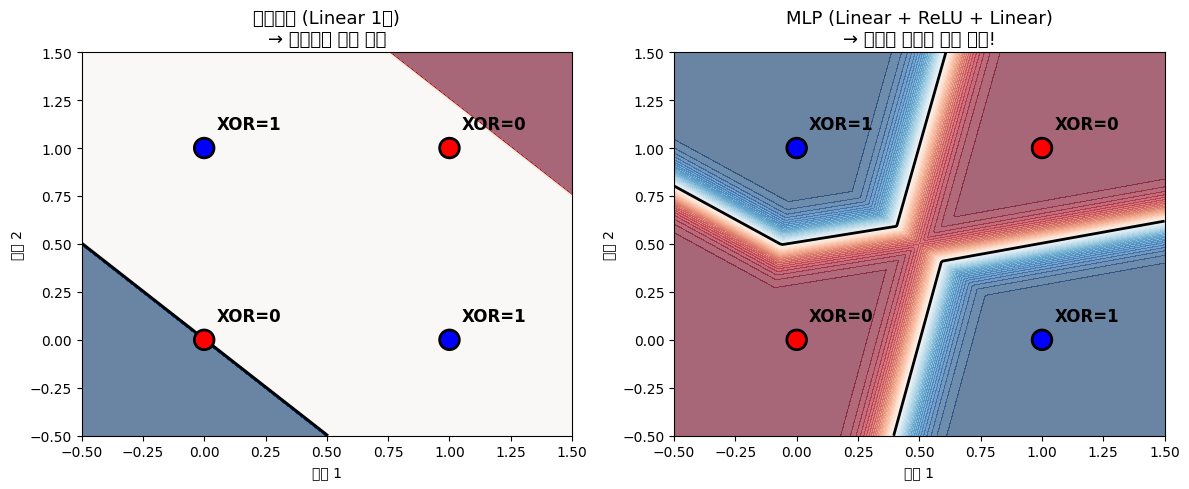

왼쪽: 직선 하나로는 빨강/파랑을 분리 불가
오른쪽: ReLU 덕분에 곡선 경계가 생겨서 분리 성공!


In [12]:
# 결정 경계 시각화
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 격자 생성
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

colors = ['red' if label == 0 else 'blue' for label in y.numpy().flatten()]
labels_text = ['0', '1', '1', '0']

for ax, model_to_plot, title in [
    (axes[0], model_single, '퍼셉트론 (Linear 1개)\n→ 직선으로 분리 실패'),
    (axes[1], model_mlp, 'MLP (Linear + ReLU + Linear)\n→ 비선형 경계로 분리 성공!')
]:
    with torch.no_grad():
        zz = model_to_plot(grid).numpy().reshape(xx.shape)
    
    ax.contourf(xx, yy, zz, levels=50, cmap='RdBu', alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[:,0].numpy(), X[:,1].numpy(), c=colors, s=200, 
              edgecolors='black', linewidth=2, zorder=5)
    for i in range(4):
        ax.annotate(f'XOR={labels_text[i]}', (X[i,0].item()+0.05, X[i,1].item()+0.1),
                   fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('입력 1')
    ax.set_ylabel('입력 2')

plt.tight_layout()
plt.show()
print("왼쪽: 직선 하나로는 빨강/파랑을 분리 불가")
print("오른쪽: ReLU 덕분에 곡선 경계가 생겨서 분리 성공!")

---
# 실습 5: Autograd로 역전파 체험 (교안 슬라이드 26)

> **교안 연결**: 역전파는 손실 값을 가지고 출력층에서 거꾸로 계산하면서 가중치를 업데이트합니다.  
> 이때 **미분**이 필요한데, PyTorch의 **Autograd**가 자동으로 해줍니다.

### requires_grad=True로 미분 추적하기

In [13]:
x = torch.tensor(2.0, requires_grad=True)  # 미분 추적 ON!
y = x**2 + 3*x + 1

y.backward()  # 역전파 실행 (미분 계산)
print(f"x = {x.item()}")
print(f"y = x² + 3x + 1 = {y.item()}")
print(f"dy/dx = 2x + 3 = {x.grad.item()}")  # 7.0
print()
print("→ PyTorch가 미분을 자동으로 계산했습니다!")
print("→ 이것이 역전파의 핵심: 각 가중치가 오차에 준 영향을 자동 계산")

x = 2.0
y = x² + 3x + 1 = 11.0
dy/dx = 2x + 3 = 7.0

→ PyTorch가 미분을 자동으로 계산했습니다!
→ 이것이 역전파의 핵심: 각 가중치가 오차에 준 영향을 자동 계산


In [14]:
# 미분 추적 OFF: 평가(추론)할 때는 미분이 필요 없습니다
with torch.no_grad():  # 이 블록 안에서는 미분 추적 OFF
    y2 = x**2 + 5*x + 10
    print(f"no_grad 블록 내부 계산: y2 = {y2.item()}")
    print("→ 이 블록에서는 backward() 불가 (미분 추적 안 함)")
    print("→ 학습할 때: ON / 평가할 때: OFF")

no_grad 블록 내부 계산: y2 = 24.0
→ 이 블록에서는 backward() 불가 (미분 추적 안 함)
→ 학습할 때: ON / 평가할 때: OFF


---
# 실습 6: MNIST 데이터 + DataLoader 구성 (교안 슬라이드 37)

> **교안 연결**: MLP로 숫자 분류기를 만들기 위해 데이터를 준비합니다.  
> DataLoader는 데이터를 **batch 단위**로 나눠서 모델에 공급하는 역할을 합니다.

### MNIST: 손글씨 숫자 이미지 (28×28 픽셀, 0~9)

In [15]:
import pandas as pd
from torch.utils.data import DataLoader
import gzip
import struct
import numpy as np

# Fashion MNIST 데이터 로드 함수
def load_fashion_mnist(image_path, label_path):
    """Fashion MNIST .gz 파일을 읽어서 DataFrame으로 변환"""
    # 레이블 로드
    with gzip.open(label_path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    
    # 이미지 로드
    with gzip.open(image_path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
    
    # DataFrame으로 변환 (첫 번째 열이 레이블, 나머지가 픽셀값)
    df = pd.DataFrame(images)
    df.insert(0, 'label', labels)
    return df

# Fashion MNIST 데이터 로드
train_df = load_fashion_mnist(
    'FashionMNIST/raw/train-images-idx3-ubyte.gz',
    'FashionMNIST/raw/train-labels-idx1-ubyte.gz'
)
test_df = load_fashion_mnist(
    'FashionMNIST/raw/t10k-images-idx3-ubyte.gz',
    'FashionMNIST/raw/t10k-labels-idx1-ubyte.gz'
)

print(f"훈련 데이터: {train_df.shape[0]}개")
print(f"테스트 데이터: {test_df.shape[0]}개")
print(f"컬럼 수: {train_df.shape[1]}개 (정답 1개 + 픽셀 784개)")
print("\nFashion MNIST 레이블: 0=티셔츠, 1=바지, 2=풀오버, 3=드레스, 4=코트,")
print("                      5=샌들, 6=셔츠, 7=스니커즈, 8=가방, 9=앵클부츠")

훈련 데이터: 60000개
테스트 데이터: 10000개
컬럼 수: 785개 (정답 1개 + 픽셀 784개)

Fashion MNIST 레이블: 0=티셔츠, 1=바지, 2=풀오버, 3=드레스, 4=코트,
                      5=샌들, 6=셔츠, 7=스니커즈, 8=가방, 9=앵클부츠


C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648

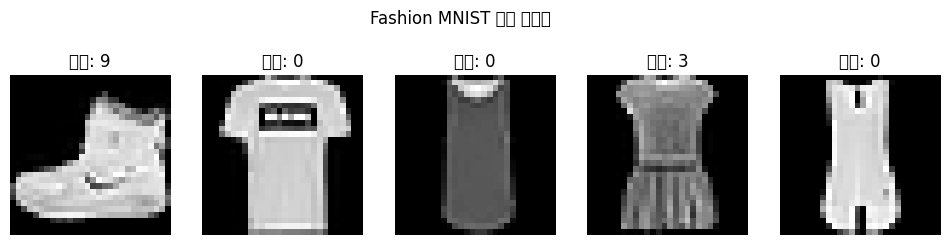

→ 28×28 = 784개의 픽셀값을 입력으로 넣으면, 0~9 중 어떤 의류인지 맞추는 것이 목표!


In [16]:
# 이미지 시각화
labels = torch.tensor(train_df.iloc[:, 0].values)
images = torch.tensor(train_df.iloc[:, 1:].values)

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i].reshape(28, 28), cmap="gray")
    plt.title(f"정답: {labels[i].item()}")
    plt.axis("off")
plt.suptitle("Fashion MNIST 의류 이미지")
plt.show()
print("→ 28×28 = 784개의 픽셀값을 입력으로 넣으면, 0~9 중 어떤 의류인지 맞추는 것이 목표!")

In [17]:
# DataLoader 구성
X_train = torch.tensor(train_df.iloc[:, 1:].values, dtype=torch.float32) / 255.0  # 0~1로 정규화
y_train = torch.tensor(train_df.iloc[:, 0].values, dtype=torch.long)

X_test = torch.tensor(test_df.iloc[:, 1:].values, dtype=torch.float32) / 255.0
y_test = torch.tensor(test_df.iloc[:, 0].values, dtype=torch.long)

train_dataset = list(zip(X_train, y_train))
test_dataset = list(zip(X_test, y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 배치 1개 꺼내서 확인
for X_batch, y_batch in train_loader:
    print(f"배치 입력 shape: {X_batch.shape}")   # [64, 784]
    print(f"배치 정답 shape: {y_batch.shape}")   # [64]
    print(f"정답 예시: {y_batch[:10]}")
    break

print(f"\n전체 배치 수: {len(train_loader)}개 (= {len(train_dataset)}개 ÷ 64)")

배치 입력 shape: torch.Size([64, 784])
배치 정답 shape: torch.Size([64])
정답 예시: tensor([1, 1, 1, 8, 9, 6, 0, 9, 1, 8])

전체 배치 수: 938개 (= 60000개 ÷ 64)


---
# 실습 7: MLP 모델 정의 (교안 슬라이드 40)

> **교안 연결**: 지금까지 배운 모든 개념을 합칩니다.  
> nn.Sequential + nn.Linear + nn.ReLU + CrossEntropyLoss + Adam

### 모델 구조: 784 → 256 → 128 → 10

In [18]:
# MLP 모델 정의
model = nn.Sequential(
    nn.Linear(784, 256),   # 입력층 → 은닉층1 (784개 픽셀 → 256개 뉴런)
    nn.ReLU(),             # 활성화 함수
    nn.Linear(256, 128),   # 은닉층1 → 은닉층2 (256 → 128)
    nn.ReLU(),             # 활성화 함수
    nn.Linear(128, 10)     # 은닉층2 → 출력층 (128 → 10개 클래스)
)

# 더미 데이터로 동작 확인
dummy = torch.randn(1, 784)  # 가짜 이미지 1장
output = model(dummy)
print(f"입력 shape: {dummy.shape}")    # [1, 784]
print(f"출력 shape: {output.shape}")   # [1, 10]
print(f"출력값 (10개 점수): {output.detach().numpy().round(2)}")
print(f"예측 숫자: {torch.argmax(output).item()}") 
print("→ 아직 학습 전이라 엉터리 예측!")

입력 shape: torch.Size([1, 784])
출력 shape: torch.Size([1, 10])
출력값 (10개 점수): [[-0.1  -0.06 -0.2  -0.05 -0.04 -0.   -0.01 -0.04 -0.08  0.05]]
예측 숫자: 9
→ 아직 학습 전이라 엉터리 예측!


In [19]:
# 손실함수 & 옵티마이저 설정
loss_fn = nn.CrossEntropyLoss()  # 다중 분류 손실함수
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 옵티마이저

print("손실함수: CrossEntropyLoss (다중 분류)")
print("옵티마이저: Adam (적응적 학습률)")
print("학습률: 0.001")

손실함수: CrossEntropyLoss (다중 분류)
옵티마이저: Adam (적응적 학습률)
학습률: 0.001


---
# 실습 8: 학습 실행 + 결과 확인 (교안 슬라이드 43)

> **교안 연결**: 학습 루프 5단계를 실제로 실행합니다.  
> zero_grad → forward → loss → backward → step

### 모델 학습 (5 Epoch)

In [20]:
# 학습 실행
epochs = 5
loss_history = []

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        # === 학습 루프 5단계 ===
        optimizer.zero_grad()              # 1단계: 기울기 초기화
        outputs = model(X_batch)           # 2단계: 순전파
        loss = loss_fn(outputs, y_batch)   # 3단계: 손실 계산
        loss.backward()                    # 4단계: 역전파
        optimizer.step()                   # 5단계: 가중치 업데이트
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    avg_loss = total_loss / len(train_loader)
    acc = correct / total * 100
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | 정확도: {acc:.1f}%")

print("\n학습 완료!")

Epoch 1/5 | Loss: 0.5214 | 정확도: 81.5%
Epoch 2/5 | Loss: 0.3673 | 정확도: 86.6%
Epoch 3/5 | Loss: 0.3340 | 정확도: 87.7%
Epoch 4/5 | Loss: 0.3105 | 정확도: 88.5%
Epoch 5/5 | Loss: 0.2936 | 정확도: 89.1%

학습 완료!


C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


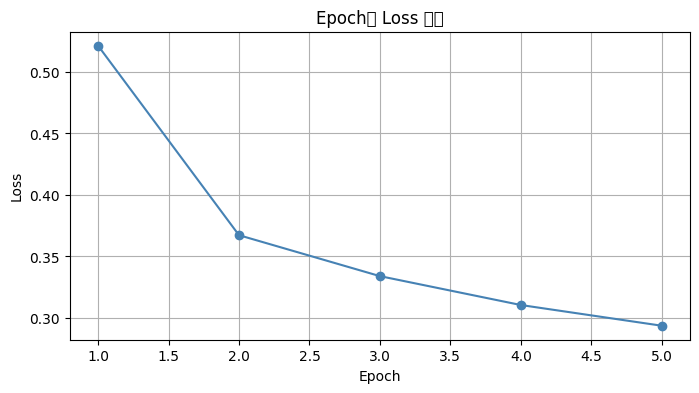

→ Epoch가 진행될수록 Loss가 줄어듭니다 = 모델이 학습하고 있습니다!


In [21]:
# Loss 추이 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), loss_history, marker='o', color='steelblue')
plt.title("Epoch별 Loss 변화")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
print("→ Epoch가 진행될수록 Loss가 줄어듭니다 = 모델이 학습하고 있습니다!")

In [22]:
# 테스트 데이터로 최종 평가
correct = 0
total = 0

with torch.no_grad():  # 평가할 때는 미분 추적 OFF
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print(f"테스트 정확도: {correct/total*100:.1f}% ({correct}/{total})")

테스트 정확도: 87.8% (8785/10000)


C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 5262

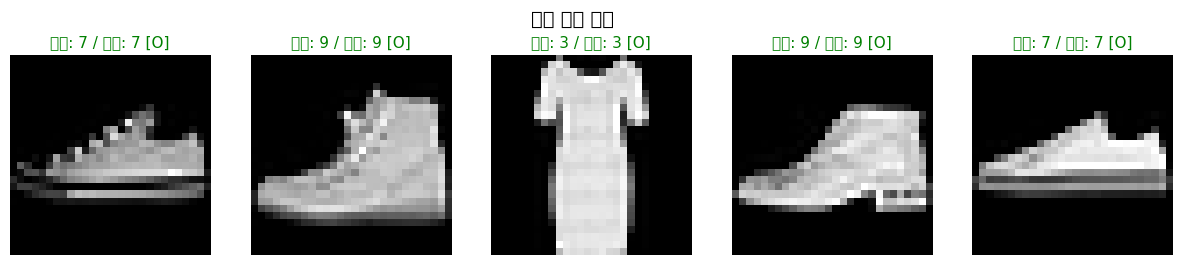

In [23]:
# 실제 추론 테스트: 랜덤 이미지 5장 뽑아서 예측
indices = torch.randint(0, len(X_test), (5,))
sample_images = X_test[indices]
sample_labels = y_test[indices]

with torch.no_grad():
    sample_outputs = model(sample_images)
    sample_preds = torch.argmax(sample_outputs, dim=1)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    correct_str = "O" if sample_preds[i] == sample_labels[i] else "X"
    color = 'green' if sample_preds[i] == sample_labels[i] else 'red'
    plt.title(f"예측: {sample_preds[i].item()} / 정답: {sample_labels[i].item()} [{correct_str}]", 
              color=color, fontsize=11)
    plt.axis("off")
plt.suptitle("모델 추론 결과", fontsize=14)
plt.show()

---
# 마무리

이번 실습에서 다룬 내용을 정리합니다:

| 실습 | 핵심 개념 | PyTorch 코드 |
|------|----------|-------------|
| 실습 1 | 텐서 = PyTorch의 기본 자료구조 | `torch.tensor()` |
| 실습 2 | 퍼셉트론 = 직선 하나 | `nn.Linear(1, 1)` |
| 실습 3 | 층 쌓기 = 더 복잡한 문제 해결 | `nn.Sequential(...)` |
| 실습 4 | 활성화 함수 = 직선 → 곡선 | `nn.ReLU()` |
| 실습 5 | 역전파 = 자동 미분 | `loss.backward()` |
| 실습 6 | 배치 처리 = 효율적 학습 | `DataLoader(batch_size=64)` |
| 실습 7 | MLP = 여러 층의 퍼셉트론 | `Sequential(Linear, ReLU, ...)` |
| 실습 8 | 학습 루프 5단계 | `zero_grad → forward → loss → backward → step` |